In [1]:
import numpy as np
import torch
from Plotting import *
from matplotlib import pyplot as plt

/tmp/ipykernel_73556/591653977.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rmses = np.array(rmses)[:13056]


../Results/New-model-deep/RMSE_over_time.pdf


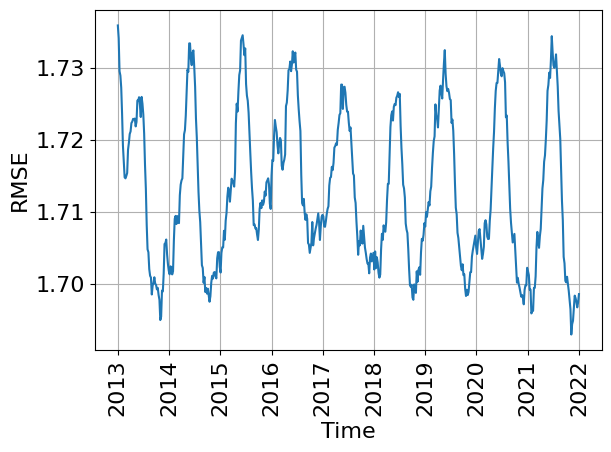

In [12]:
# RMSE over time
model = "New-model-deep"

rmses = torch.load(f"../Results/{model}/RMSE_over_time.pt", weights_only=True)
rmses = np.array(rmses)[:13056]

def exponential_moving_average(data, alpha):
    ema = [data[0]]
    for value in data[1:]:
        ema.append(alpha * value + (1 - alpha) * ema[-1])
    return np.array(ema)

B = 24
batches = rmses.reshape((-1,B))
batch_means= batches.mean(axis=-1)

smooth = exponential_moving_average(batch_means, alpha=.05)
plot_RMSE_over_time(smooth)
plot_io(show=True, save_name=f"../Results/{model}/RMSE_over_time")

../Results/New-model-deep/Coefficient_RMSE.pdf


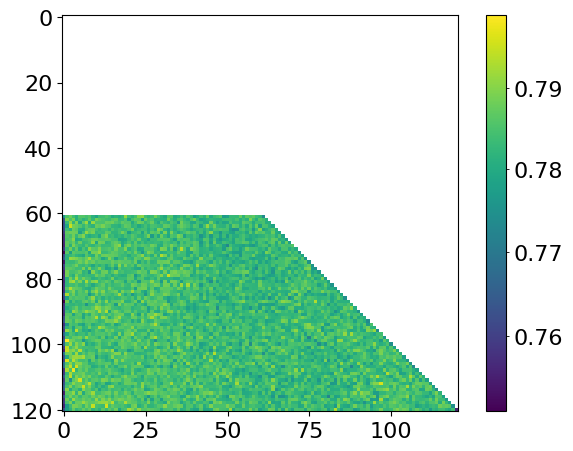

In [15]:
data = torch.load(f"../Results/{model}/Coefficient_RMSE.pt", weights_only=True)

plot_coeffs_as_img(data, save_name=f"../Results/{model}/Coefficient_RMSE")